In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , Normalization
import logging
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error , r2_score

logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(logging.ERROR)



In [25]:
df = pandas.read_csv("./dataset/ds.csv")

print(df.shape)


(1371, 5)


In [26]:
df.head()


,3.6216,8.6661,-2.8073,-0.44699,0
0,4.54590,8.1674,-2.4586,-1.46210,0
1,3.86600,-2.6383,1.9242,0.10645,0
2,3.45660,9.5228,-4.0112,-3.59440,0
3,0.32924,-4.4552,4.5718,-0.98880,0
4,4.36840,9.6718,-3.9606,-3.16250,0


In [27]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1371 entries, 0 to 1370
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   3.6216    1371 non-null   float64
 1   8.6661    1371 non-null   float64
 2   -2.8073   1371 non-null   float64
 3   -0.44699  1371 non-null   float64
 4   0         1371 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [28]:
df.isnull().sum()

3.6216      0
8.6661      0
-2.8073     0
-0.44699    0
0           0
dtype: int64

In [29]:
df.duplicated().sum()

np.int64(24)

In [30]:
X = df.drop(columns=['0'])
y = df['0']

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=0)


X_train shape : (1096, 4)
X_test shape : (275, 4)
y_train shape : (1096,)
y_test shape : (275,)


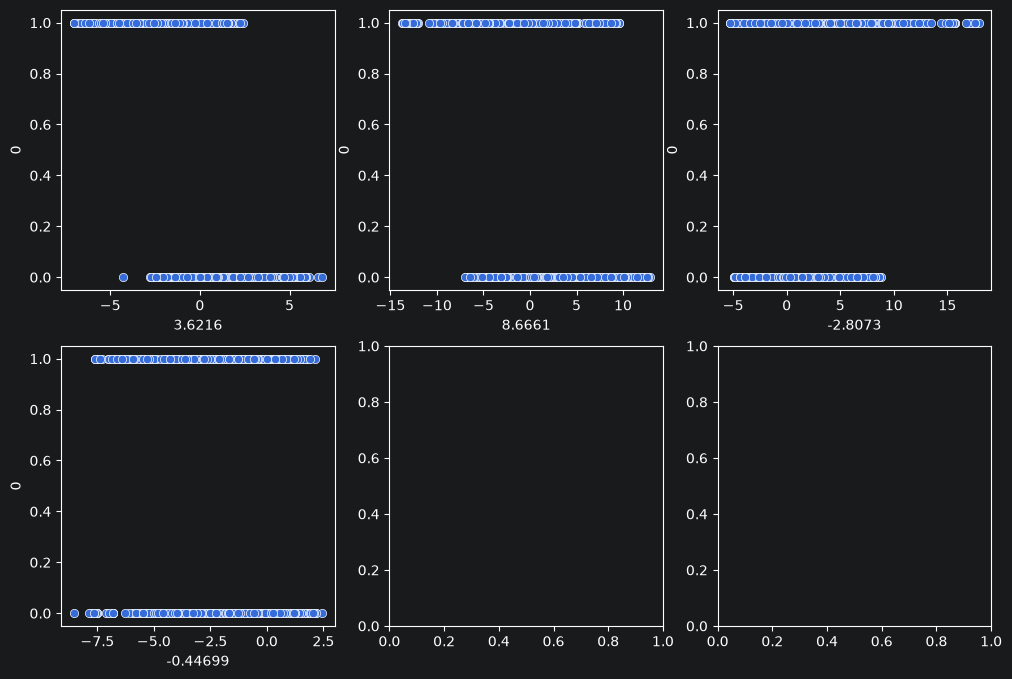

In [31]:
print(f"X_train shape : {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"y_test shape : {y_test.shape}")

fig , ax = plt.subplots(2,3, figsize=(12,8))
ax = ax.flatten()

for i , col in enumerate(X.columns):
    sns.scatterplot(data=df, x=col, y='0', ax=ax[i])

plt.show()


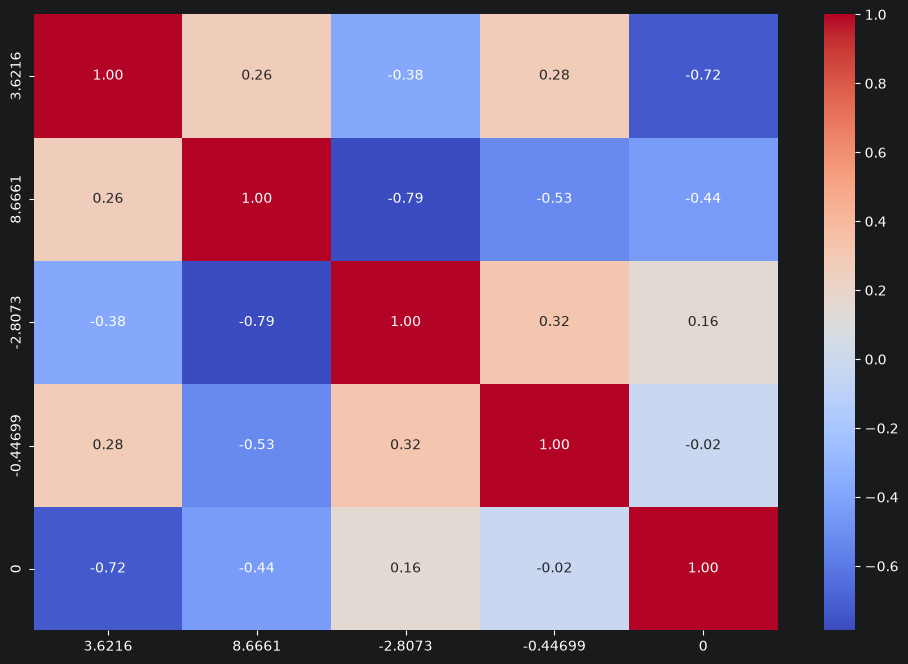

In [32]:
corr = df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr , annot=True , cmap="coolwarm" , fmt=".2f")
plt.show()


In [33]:
X_train = X_train.to_numpy(np.float32)
X_test = X_test.to_numpy(dtype=np.float32)

norm_l = Normalization(axis=-1)
norm_l.adapt(X_train)
X_train_norm = norm_l(X_train)
X_test_norm = norm_l(X_test)

print(f"X_train normalization : {X_train_norm}")
print(f"X_test normalization : {X_test_norm}")

X_train normalization : [[-1.23839    -1.4342036   2.114168    0.13992456]
 [-0.28386986  0.21640332 -1.0233376  -0.71665704]
 [-0.68101066 -1.4075298   1.0024976   0.98110825]
 ...
 [ 0.08149905  0.3515021  -1.4339193  -1.5294989 ]
 [ 1.3033565   1.585943   -1.3480988  -1.6940593 ]
 [ 1.3129443   0.986621   -0.81923205  0.00744695]]
X_test normalization : [[-0.1367997  -0.20221318 -0.48431793  0.9262642 ]
 [ 1.6909702  -0.314148   -0.25951356  1.0963672 ]
 [-1.3878751  -2.4398565   3.18782     0.20648266]
 ...
 [-0.2623168  -0.37450108 -0.4464853   0.8634043 ]
 [-1.1958326  -2.561983    2.7955737  -0.68706197]
 [-1.694651    0.7202896  -0.2023649  -2.0403845 ]]


In [34]:
Xt = np.tile(X_train_norm , (1000,1))
Yt = np.tile(y_train , (1000,1))

print(f"Xt shape : {Xt.shape}")
print(f"Yt shape : {Yt.shape}")


Xt shape : (1096000, 4)
Yt shape : (1000, 1096)


In [35]:
tf.random.set_seed(1234)
model = Sequential([
    tf.keras.Input(shape=(X_train.shape[1],)),
    Dense(units=4,activation='sigmoid',name='layer_1'),
    Dense(units=8,activation='sigmoid',name='layer_2'),
    Dense(units=1,activation='sigmoid',name='layer_3')
])



In [36]:
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer_1 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_2 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69 (276.00 B)

 Trainable params: 69 (276.00 B)

 Non-trainable params: 0 (0.00 B)

In [37]:
L1_num_param = X_train.shape[1] * 4 +4
L2_num_param = 4*8+8
L3_num_param = 8*1+1

print(f"L1_param : {L1_num_param}\nL2_num_param: {L2_num_param}\nL3_num_param : {L3_num_param}")


L1_param : 20
L2_num_param: 40
L3_num_param : 9


In [38]:
w1,b1 = model.get_layer("layer_1").get_weights()
w2,b2 = model.get_layer("layer_2").get_weights()
w3,b3 = model.get_layer("layer_3").get_weights()

print(f"w1 : {w1} and b1: {b1}")
print(f"w2: {w2} and b2 : {b2}")
print(f"w3: {w3} and b3 : {b3}")


w1 : [[ 0.720733    0.7728178   0.34595698 -0.3742947 ]
 [ 0.6791443  -0.78680444  0.21481246  0.10326576]
 [-0.59594667 -0.7920785   0.22238654  0.10009712]
 [ 0.33570236  0.6508735  -0.07213402  0.07355952]] and b1: [0. 0. 0. 0.]
w2: [[ 0.13281447 -0.16375315  0.22559929 -0.18670785 -0.60812914 -0.48755136
   0.64757115  0.05606997]
 [ 0.21462423 -0.5983271  -0.4741635   0.6540471  -0.06384456 -0.38402152
   0.4405052   0.54635924]
 [-0.07945049  0.48444158  0.61459917 -0.18243682  0.134718    0.11511636
   0.6396592   0.66782695]
 [-0.08942413  0.60442644  0.2034474   0.6200821  -0.16949826 -0.6675981
  -0.1262809   0.15463948]] and b2 : [0. 0. 0. 0. 0. 0. 0. 0.]
w3: [[ 0.5985668 ]
 [-0.16055745]
 [-0.510113  ]
 [-0.694805  ]
 [-0.78924406]
 [-0.321908  ]
 [ 0.77373016]
 [ 0.6798403 ]] and b3 : [0.]


In [42]:
model.compile(
    loss = tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=['accuracy']
)

history = model.fit(
    X_train_norm , y_train ,
    epochs=20, batch_size=32,
    validation_data=(X_test_norm,y_test)
)


Epoch 1/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9918 - loss: 0.0270 - val_accuracy: 0.9891 - val_loss: 0.0268
Epoch 2/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9900 - loss: 0.0246 - val_accuracy: 0.9891 - val_loss: 0.0265
Epoch 3/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9881 - loss: 0.0239 - val_accuracy: 0.9891 - val_loss: 0.0255
Epoch 4/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9881 - loss: 0.0233 - val_accuracy: 0.9891 - val_loss: 0.0249
Epoch 5/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9881 - loss: 0.0230 - val_accuracy: 0.9891 - val_loss: 0.0244
Epoch 6/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9881 - loss: 0.0227 - val_accuracy: 0.9891 - val_loss: 0.0240
Epoch 7/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9881 - loss: 0.0224 - val_accuracy: 0.9891 - val_loss: 0.0237
Epoch 8/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9881 - loss: 0.0222 - val_accuracy: 0.9891 - val_loss

In [43]:
prediction = model.predict(X_test_norm[:5])
decisions = (prediction>=0.5).astype(int)

print(f"Вероятности: {prediction}")
print(f"Решение (классы): {decisions}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
Вероятности: [[9.9581087e-01]
 [1.4855378e-04]
 [9.9527496e-01]
 [1.3328026e-04]
 [1.3370873e-04]]
Решение (классы): [[1]
 [0]
 [1]
 [0]
 [0]]
